In [1]:
from langgraph.graph import StateGraph, START, END
from typing import List, Dict, Optional, TypedDict, Annotated
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import operator

load_dotenv()

True

In [2]:
model = ChatGroq(model="openai/gpt-oss-20b")

In [3]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(
        description = 'Detailed feedback for the essay.'
        )
    score: int = Field(
        description = 'Score out of 10', gt=0, le=10
    )

stucture kroar karon model generic passage akare answer dey, tai ammra structured output nnniye ashchi VVVIMP

In [4]:
structured_model = model.with_structured_output(EvaluationSchema)

In [5]:
essay = """
# The Importance of Education

Education plays an important role in our lives. It helps us gain knowledge, develop skills, and understand the world around us. A good education allows people to make better decisions and build a better future.

Schools teach students many useful subjects, such as science, mathematics, languages, and history. Education also teaches important values like discipline, respect, and responsibility. These lessons help people become productive members of society.

Education creates opportunities. It can help people find better jobs, solve problems, and contribute to their communities. Without education, many people may struggle to reach their goals.

In conclusion, education is a powerful tool for personal growth and social progress. Everyone should have access to quality education because it helps individuals and societies improve.

"""

In [6]:
prompt = f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10"
result = structured_model.invoke(prompt)
print(result)

feedback='The essay demonstrates a solid grasp of academic English with clear organization and logical progression of ideas. The sentence structures are varied, and the vocabulary is appropriate for the topic. However, there are a few areas for improvement: 1) Some sentences are overly long and could benefit from being split for clarity. 2) Occasional minor grammatical errors (e.g., subject-verb agreement, preposition choice) detract from the overall polish. 3) The conclusion could be strengthened by explicitly summarizing the key points rather than merely restating them. 4) Transition phrases between paragraphs would help the flow. Overall, the language quality is strong, but attention to these details would elevate the essay to a higher level.' score=8


In [7]:
result.feedback

'The essay demonstrates a solid grasp of academic English with clear organization and logical progression of ideas. The sentence structures are varied, and the vocabulary is appropriate for the topic. However, there are a few areas for improvement: 1) Some sentences are overly long and could benefit from being split for clarity. 2) Occasional minor grammatical errors (e.g., subject-verb agreement, preposition choice) detract from the overall polish. 3) The conclusion could be strengthened by explicitly summarizing the key points rather than merely restating them. 4) Transition phrases between paragraphs would help the flow. Overall, the language quality is strong, but attention to these details would elevate the essay to a higher level.'

In [8]:
result.score

8

In [9]:
class EssayState(BaseModel):
    essay: str
    analysis_feedback: str = ""
    language_feedback: str = ""
    evaluate_feedback: str = ""
    overall_feedback: str = ""
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float = 0.0

In [10]:
def evaluate_analysis(state: BaseModel):
    prompt = f"""
        Evalueate the depth analysis of the following essay {state.essay} and provide a feedback and
        assign a score of 10 
    """
    response = structured_model.invoke(prompt)

    return{
        'analysis_feedback': response.feedback,
        'individual_scores': [response.score]
    }


In [11]:
def evaluate_language(state: EssayState):
    prompt = f"""
        Evalueage the language quality of the following essay {state.essay} and provide a feedback and
        assign a score of 10 
    """
    response = structured_model.invoke(prompt)

    return{
        'language_feedback': response.feedback,
        'individual_scores': [response.score]
    }


In [13]:
def evaluate_thought(state: EssayState):
    prompt = f"""
        Evalueage the clarity of the thought of the following essay {state.essay} and
        provide a feedback and assign a score of 10 
    """
    response = structured_model.invoke(prompt)

    return{
        'evaluate_feedback': response.feedback,
        'individual_scores': [response.score]
    }

In [14]:
def final_evaluation(state: EssayState):
    prompt = f"""
        Based on the following feedbacks create a summarized feedback
        Analysis Feedback: {state.analysis_feedback},
        Language Feedback: {state.language_feedback},
        Evaluate Feedback: {state.evaluate_feedback}
        provide a feedback and assign a score of 10 
    """

    response = model.invoke(prompt).content

    avg_score = sum(state.individual_scores)/len(state.individual_scores)

    return{
        'overall_feedback': response,
        'avg_score': avg_score
    }

In [15]:
graph = StateGraph(EssayState)

graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge(
    [
        "evaluate_analysis",
        "evaluate_language",
        "evaluate_thought"
    ],
    "final_evaluation"
)

graph.add_edge('final_evaluation', END)

workflow = graph.compile()

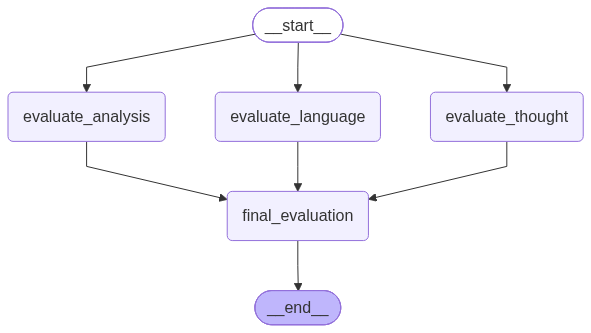

In [16]:
workflow

In [17]:
essay2 = """
# The Importance of Protecting Nature

Nature is an important part of our lives. It provides us with clean air, fresh water, food, and many other resources. Plants, animals, and humans depend on the environment to survive.

Today, pollution and deforestation are harming the planet. Many forests are being destroyed, and animals are losing their homes. Waste and harmful chemicals also damage rivers, oceans, and the air we breathe.

We can protect nature by taking simple actions. We can plant trees, save water, reduce waste, and recycle materials. People should also use resources carefully and keep their surroundings clean.

Protecting nature is everyone's responsibility. If we take care of the environment today, future generations will have a healthier and safer planet to live on.
"""

In [18]:
initial_state = {
    'essay': essay2
}

result = workflow.invoke(initial_state)

In [21]:
print(result["analysis_feedback"])

The essay offers a clear, straightforward overview of the importance of protecting nature, highlighting key environmental benefits and threats such as pollution and deforestation. It successfully identifies simple individual actions—planting trees, conserving water, reducing waste, and recycling—that readers can adopt. The structure is logical: introduction of the issue, explanation of problems, actionable solutions, and a concluding call to collective responsibility. However, the depth of analysis is limited; it could be strengthened by providing specific examples, data, or a discussion of systemic causes and broader impacts. The language is accessible and suitable for a general audience, but the essay lacks nuanced arguments or exploration of counterpoints. Overall, it serves as an effective introductory piece but would benefit from deeper exploration and evidence to elevate its analytical depth.

